# Logistic regression

## Régression Linéaire vs Régression Logistique

Contrairement à la **régression linéaire**, qui prédit une valeur numérique continue, la **régression logistique** est utilisée pour la classification. Elle prédit la **probabilité** qu'un événement appartienne à une classe donnée.

Mathématiquement, nous cherchons à estimer :

$$P(y=1|X)$$

Cette expression représente la probabilité que l'étiquette $y$ soit égale à $1$ (classe cible), sachant le vecteur de caractéristiques (features) $X$.

En résumé: 
* **Régression Linéaire :** Prédit $y \in \mathbb{R}$ (ex: prix d'une maison).
* **Régression Logistique :** Prédit $P(y=1|X) \in [0, 1]$ (ex: probabilité qu'un email soit un spam).

---

## Synthetic Data

On considère un problème de classification binaire où la variable cible est $y \in \{0, 1\}$. 

On suppose que la distribution conditionnelle de chaque classe $k$ (pour $k = 0, 1$) suit une **loi normale** (gaussienne) :

$$p(x|y = k) = \mathcal{N}(\mu_k, \Sigma_k)$$

Où :
* $\mu_k$ représente le **vecteur moyen** de la classe $k$: déterminent la position centrale de chaque groupe (sommet de la cloche).
* $\Sigma_k$ représente la **matrice de covariance** de la classe $k$: déterminent la dispersion et la forme des nuages de points.

**Distribution gaussienne (ou loi Normale)**: Une distribution est dite normale lorsque la majorité des données se concentre autour de la moyenne ($\mu$), et que les données deviennent de plus en plus rares à mesure que l'on s'en éloigne. Cela crée une courbe symétrique en forme de cloche.

In [10]:
from utility import gen_data_twogaussians_2d
import numpy as np
import matplotlib.pyplot as plt

# création d'un jeu de données artificiel
# classe 1
# 100 samples 
n1 = 100
# tous les points de (1) seront générés autour de (0,2)
mu1 = np.array([0,2])
S1 = 1.5*np.array([[1,0.1],[0.1,1]])
# classe 2
# 100 samples
n2 = 100
mu2 = np.array([-2,-2])
S2 = 3.5*np.array([[1,-0.25],[-0.25,0.5]])

In [11]:
# génère les données d'entraînement
# X_train: tableau; array(n1+n2,2)
# Y_train: vecteur; array(n1+n2,)
X_train, Y_train = gen_data_twogaussians_2d(mu1,S1,mu2,S2,n1,n2)

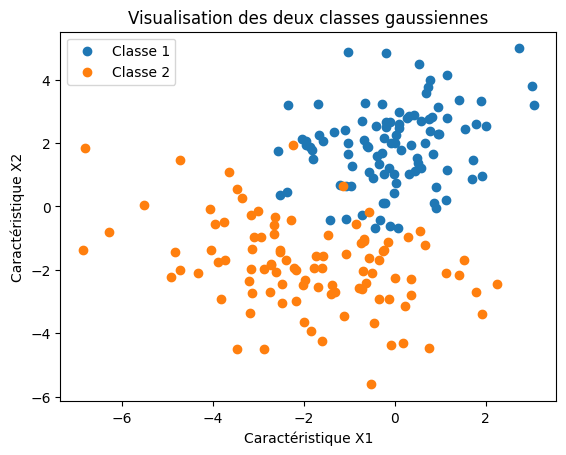

In [12]:
# affichage des données via scatter et un masquage booléen
# X_train[Y_train == 1, 0]: masque booléen Vrai si le point appartient à la classe 1, 0: colonne 1 (axe x)
# -> coordonnées X de tous les points de la classe 1.
# X_train[Y_train == 1, 1]: coordonées Y de tous les points de la classe 1.
plt.scatter(X_train[Y_train == 1, 0], X_train[Y_train == 1, 1], label="Classe 1")
plt.scatter(X_train[Y_train == 2, 0], X_train[Y_train == 2, 1], label="Classe 2")

plt.title("Visualisation des deux classes gaussiennes")
plt.xlabel("Caractéristique X1")
plt.ylabel("Caractéristique X2")

plt.legend()
plt.show()

La **régression logistique** est un modèle de classification binaire qui prédit la probabilité qu'une observation appartienne à la classe 1. Contrairement à une décision brute, elle permet de quantifier l'incertitude de la prédiction avec une valeur comprise entre 0 et 1.  

Le modèle calcule d'abord un score linéaire. Pour transformer ce score en probabilité, on utilise la fonction sigmoïde. Cette étape est essentielle car elle permet de mesurer la confiance du modèle : un score proche de zéro indique une grande incertitude (probabilité proche de 0.5), tandis qu'un score élevé indique une forte certitude.  

La frontière de décision reste linéaire (une droite ou un plan), mais la sortie est rendue non linéaire par la sigmoïde. Cette probabilité permet aussi d'ajuster le seuil de décision selon les besoins, par exemple en étant plus conservateur avec un seuil à 0.9 au lieu de 0.5.  

Pour apprendre, le modèle cherche à minimiser une fonction de perte appelée entropie croisée binaire (binary cross-entropy). Cette fonction mesure l'écart entre la probabilité prédite et la classe réelle, en pénalisant très fortement les erreurs commises avec une grande confiance.

**Paramètres clés de la Logistic Regression:**

- penalty : définit le type de correction (l1, l2, elasticnet ou None) pour éviter le surapprentissage: On ajoute une "amende" au modèle s'il donne trop d'importance à certaines caractéristiques (features).

- C : contrôle la force de la correction. Une valeur faible simplifie le modèle, une valeur élevée permet au modèle de s'adapter davantage aux données.

- solver : l'algorithme qui calcule la solution.
    * lbfgs est le choix par défaut, polyvalent et robuste, pénalité l2 uniquement.
    * liblinear est bon pour les petits jeux de données, uniquement pour la classification binaire.
    * saga permet d'utiliser tous les types de corrections et est très rapide sur de grands jeux de données.  

- max_iter : le nombre de tentatives de calcul autorisées pour trouver la solution (100 par défaut).

- class_weight : utilisé pour ajuster l'importance de chaque groupe si l'un est plus présent que l'autre dans les données.

In [15]:
from sklearn import linear_model
# penalty="none": pas dé régularisation => on fait confiance aux données
# solver="lbgfs": algortihme pour optimiser les coefficients
clf_reglog = linear_model.LogisticRegression(penalty=None, solver="lbfgs")
# le modèle calcule les meilleurs coefficients pour que la régression logistique sépare au mieux les deux classes 
# via score + sigmoïde
clf_reglog.fit(X_train, Y_train)

/home/nathan/python-envs/ITI4-1gO1oX6A/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

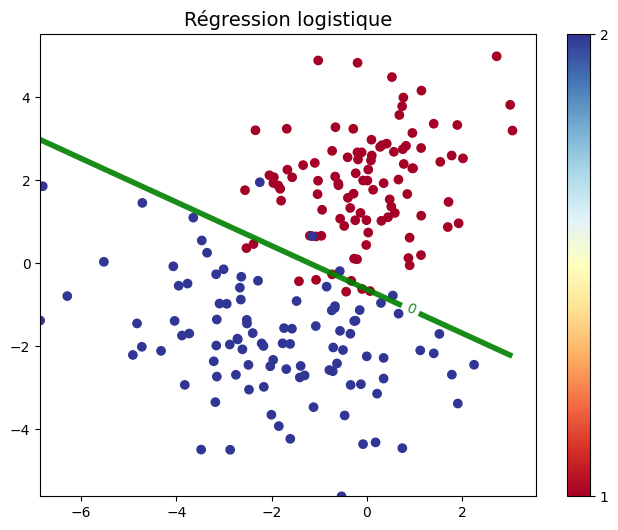

In [16]:
from utility import plot_decision_regions_2d
plot_decision_regions_2d(X_train, Y_train, clf_reglog,
                        resolution=0.02,
                        title="Régression logistique")

La droite verte représente chaque point où le score calculé par le modèle est égal à 0. À cet endroit, la fonction sigmoïde renvoie une probabilité exactement égale à 0.5 (50%). Le modèle hésite totalement entre la classe 1 et la classe 2, l'incertitude est maximale.

## Spam classification

Désormais, le problème est le suivant: on reçoit trop de mails et on veut prédire où les ranger dans la boite mail. On a un dataset de 4601 mails à disposition, avec 57 features. Le but est de classifier un email de spam (classe 1) ou de non-spam (classe 0).

- 48 caractéristiques, comprises entre 0 et 100, indiquant le pourcentage de mots d'un message correspondant à un mot donné sur une liste fixe. Cette liste contient des mots tels que « affaires », « gratuit », etc.  
- 6 caractéristiques, dans [0, 100], indiquant le pourcentage de caractères du courriel correspondant à un caractère donné.
parmi les caractères suivants : "(", "[", "!", "$", "#"
- Les caractéristiques 55 à 57 représentent respectivement la longueur moyenne, la longueur la plus longue et la somme des
longueurs de séquences ininterrompues de lettres majuscules.

In [25]:
dataspam = np.loadtxt("spambase/spambase.data", delimiter=",")
features_name = np.genfromtxt("spambase/spambase_variables.csv", 
                             delimiter=",", dtype="str")
features_name = features_name[:,0]

In [26]:
# inputs
X = dataspam[:,0:57]
# output
Y = dataspam[:,-1]
print(f"X contient {X.shape[0]} samples et {X.shape[1]} features")

X contient 4601 samples et 57 features


In [34]:
# méthode 1
unique, count =  np.unique(Y, return_counts=True)

for u, c in zip(unique, count):
    print(f"classe {u}: {c} samples")

print("----")

# méthode 2
count_0 = [x for x in Y if x == 0]
print(len(count_0),"mails non spams")

count_1 = [x for x in Y if x == 1]
print(len(count_1),"mails spams")

classe 0.0: 2788 samples
classe 1.0: 1813 samples
----
2788 mails non spams
1813 mails spams


X: toutes les données.  
Y: labels des données -> indique si le mail est un spam ou non.

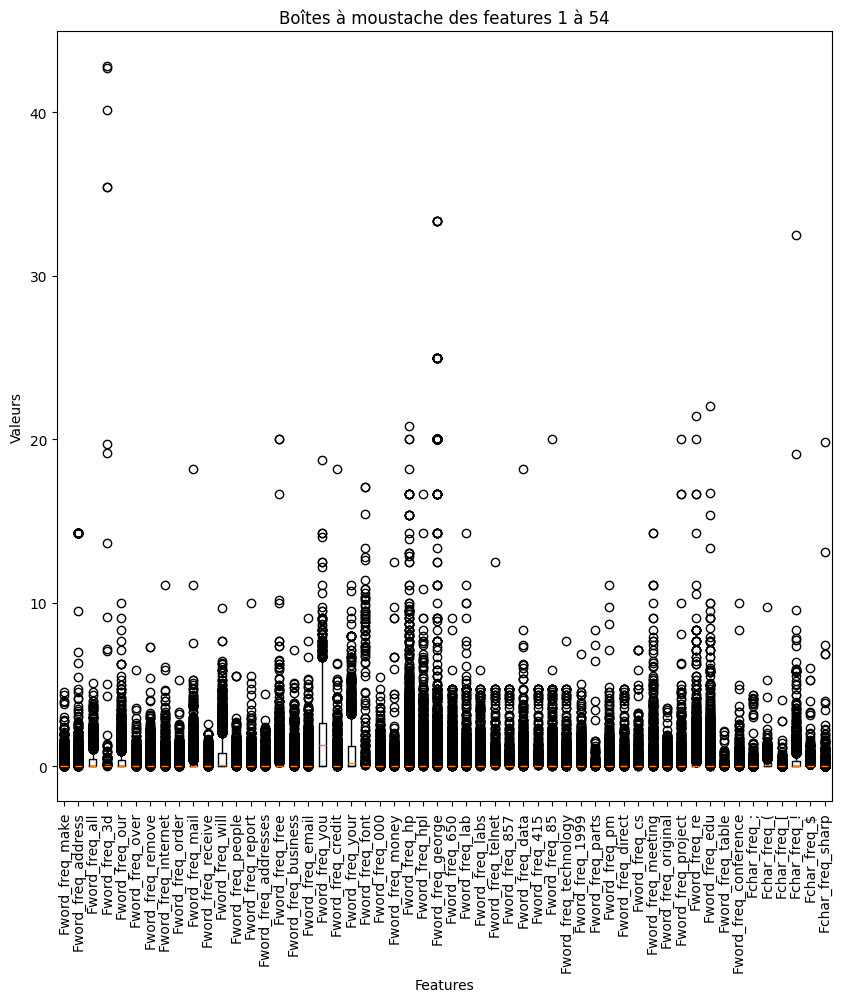

In [29]:
# features de 0 à 54 exclu 
features_name_plot = features_name[0:54]
plt.figure(figsize=(10,10))
plt.boxplot(X[:,0:54])
plt.xticks(ticks=range(1, 55), labels=[f"F{i}" for i in features_name_plot], rotation=90)
plt.title("Boîtes à moustache des features 1 à 54")
plt.xlabel("Features")
plt.ylabel("Valeurs");

- Les caractéristiques n'ont pas du tout les mêmes ordres de grandeur. Certaines restent proches de 0, tandis que d'autres montent beaucoup plus haut. Cela montre que les données ne sont pas à la même échelle.
- La plupart des boîtes sont très plates et collées à l'axe du bas. Cela indique que pour la majorité des emails, ces mots ou caractères ne sont pas présents (fréquence de 0).
- y a énormément de petits points au-dessus des boîtes. Ce sont des emails où la fréquence d'un mot est exceptionnellement élevée par rapport à la normale => outliers.
- À cause de ces différences d'échelles, ce graphique justifie qu'il faut probablement normaliser les données (les remettre sur une échelle commune) pour que la régression logistique fonctionne correctement et ne donne pas trop d'importance aux grandes valeurs par erreur.

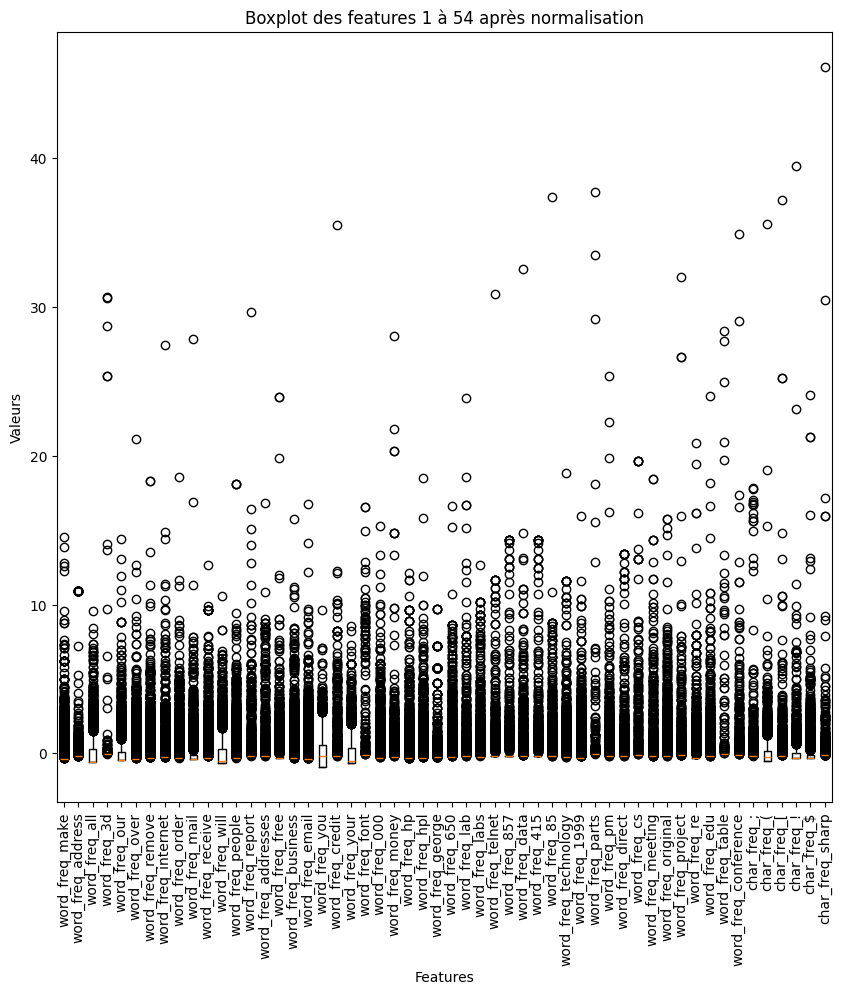

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(10,10))
plt.boxplot(X_scaled[:, 0:54])
plt.title("Boxplot des features 1 à 54 après normalisation")
plt.xlabel("Features")
plt.ylabel("Valeurs");
plt.xticks(ticks=range(1, 55), labels=features_name[0:54], rotation=90)
plt.show()

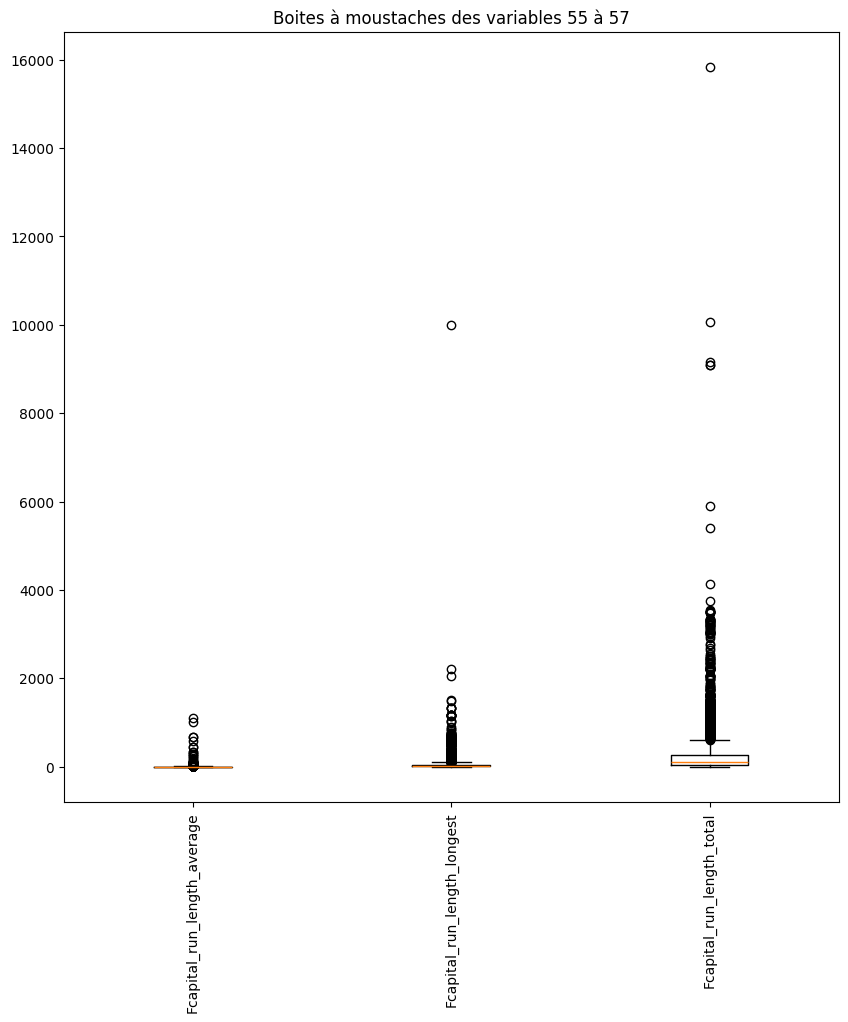

In [62]:
features_name_plot = features_name[54:57]
plt.figure(figsize=(10,10))
plt.boxplot(X[:,54:57])
plt.xticks(ticks=range(1, 4), labels=[f"F{i}" for i in features_name_plot], rotation=90)
plt.title("Boites à moustaches des variables 55 à 57")
plt.show()
n= X[:,56].size

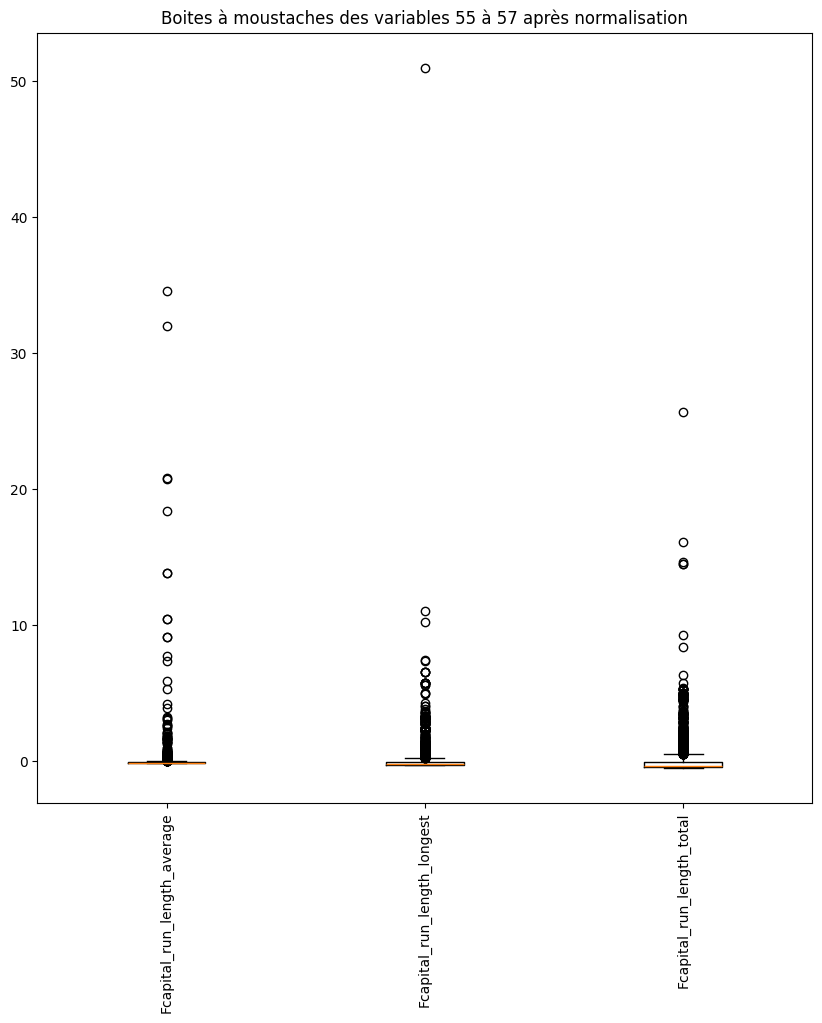

In [32]:
features_name_plot = features_name[54:57]
plt.figure(figsize=(10,10))
plt.boxplot(X_scaled[:,54:57])
plt.xticks(ticks=range(1, 4), labels=[f"F{i}" for i in features_name_plot], rotation=90)
plt.title("Boites à moustaches des variables 55 à 57 après normalisation")
plt.show()
n= X[:,56].size

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=1/3, train_size=2/3, shuffle=True, stratify=Y)

# normalise les données (toujours après séparation !)
# + il est mieux de fit sur X_train puis appliquer sur les autres données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_spam = linear_model.LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
clf_spam.fit(X_train_scaled,Y_train)
Y_pred_train = clf_spam.predict(X_train_scaled)
Y_pred_test = clf_spam.predict(X_test_scaled)

/home/nathan/python-envs/ITI4-1gO1oX6A/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [109]:
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(Y_train, Y_pred_train)
print(f"Accuracy on training data = {np.round(100*acc_train)}%")

Accuracy on training data = 93.0%


In [110]:
acc_train = accuracy_score(Y_test, Y_pred_test)
print(f"Accuracy on test data = {np.round(100*acc_train)}%")

Accuracy on test data = 92.0%


Les scores: 93% de réussite sur l'entraînement et 92% sur le test prouvent que le modèle a bien compris les règles pour différencier un spam d'un email normal sur ce dataset.  
L'écart entre le score d'entraînement et le score de test est seulement de 1%. C'est un excellent signe : cela signifie que le modèle "généralise" bien. Il n'a pas appris tes données par cœur, mais il est capable d'appliquer ses règles à de nouveaux emails qu'il n'a jamais vus avec presque la même précision.  
Le fait d'avoir normalisé les données et augmenté le nombre d'itérations (max_iter) a permis au modèle d'atteindre ces scores élevés de manière stable

In [111]:
# index contient les indices des features triés du - au + important
index = np.argsort(np.abs(np.squeeze(clf_spam.coef_)))
# on inverse l'odre pour avec les features du + au - important
index = index[::-1]
print("{:<38s}{:<18s}".format("Variables", "Coefficient"))
for var, coef in zip(features_name[index], clf_spam.coef_[0,index]):
    print("{:<28s}{:>16.2f}".format(var, coef))

Variables                             Coefficient       
word_freq_george                      -31.30
word_freq_cs                          -13.50
word_freq_857                          -5.11
word_freq_lab                          -2.52
word_freq_hp                           -2.41
word_freq_85                           -2.28
word_freq_meeting                      -2.03
word_freq_3d                            1.96
word_freq_telnet                       -1.95
word_freq_conference                   -1.72
capital_run_length_longest              1.56
word_freq_edu                          -1.46
char_freq_$                             1.12
word_freq_free                          1.09
word_freq_re                           -0.89
word_freq_remove                        0.88
word_freq_project                      -0.84
char_freq_sharp                         0.84
word_freq_000                           0.74
word_freq_hpl                          -0.72
word_freq_data                         -0.7

Les 3 features les plus importantes pour dire qu'un mail n'est pas un spam sont: 
- word_freq_george;                      
- word_freq_cs;                          
- word_freq_857;

Les emails non-spams contiennent donc les mots "georges", "cs", "857".

In [122]:
# epsilon garantit que toutes les valeurs soient strictement positives avant d 'appliquer le log
epsilon = 0.01
X_train_n = np.log(X_train + epsilon)
X_test_n = np.log(X_test + epsilon)

L'intérêt d'ajouter un epsilon est d'éviter une erreur mathématique fatale lors du calcul du logarithme sur des valeurs nulles, tout en stabilisant la distribution des données pour améliorer l'apprentissage du modèle.

In [124]:
clf_spam = linear_model.LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
clf_spam.fit(X_train_n,Y_train)

/home/nathan/python-envs/ITI4-1gO1oX6A/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [125]:
Y_pred_train = clf_spam.predict(X_train_n)
Y_pred_test = clf_spam.predict(X_test_n)

In [126]:
acc_train = accuracy_score(Y_train, Y_pred_train)
print(f"Accuracy on training data = {np.round(100*acc_train)}%")

Accuracy on training data = 95.0%


In [127]:
acc_train = accuracy_score(Y_test, Y_pred_test)
print(f"Accuracy on test data = {np.round(100*acc_train)}%")

Accuracy on test data = 95.0%


Cette fois, on obtient dans les deux cas un score de 95%, ce qui est plus haut que le score obtenu en ayant normalisé les données. L'utilisation du logarithme permet de resserrer les grandes valeurs et réduire l'impact des outliers, certaines relations deviennent plus linéaires ce qui aide la régression logistique à mieux apprendre.

| Aspect                     | Normalisation / Standardisation                       | Logarithme                                   |
|-----------------------------|-------------------------------------------------------|---------------------------------------------|
| Objectif                    | Mettre toutes les features sur la même échelle      | Réduire l’effet des valeurs extrêmes, linéariser des relations |
| Transformation              | Linéaire                                              | Non-linéaire                                 |
| Impact sur la distribution  | Moyenne et écart-type modifiés, shape conservé       | Distribution modifiée, compression des grandes valeurs |
| Sensible aux outliers ?     | Oui (les outliers restent)                            | Non (grandes valeurs compressées)           |
| Quand utile                 | Pour optimiser convergence et balance des features  | Pour features skewed ou relations exponentielles |


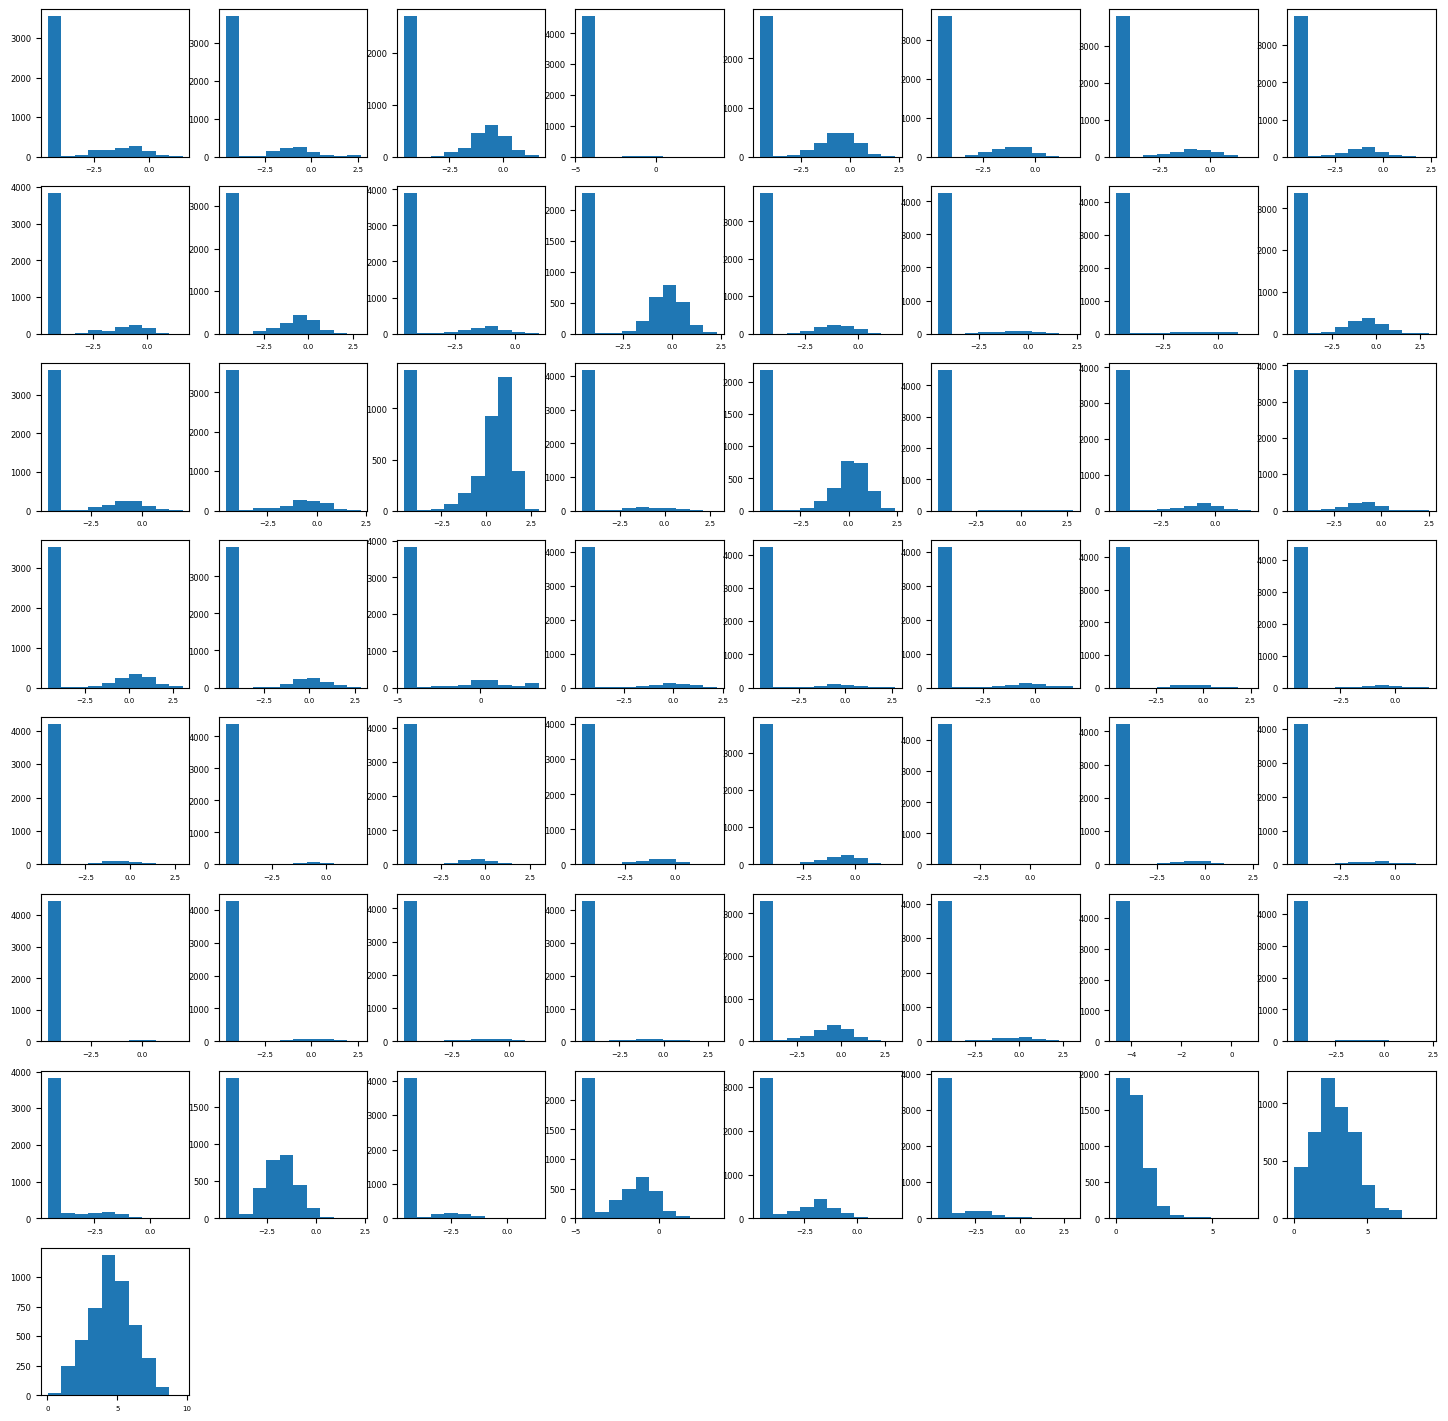

In [108]:
# histogramme de chaque feature
plt.figure(figsize=(18, 18))
vartype = "log" 
for i in range(X.shape[1]):
    plt.subplot(8,8,i+1)
    if vartype=="log":
        plt.hist(np.log(X[:,i]+epsilon))
    else:
        plt.hist(X[:,i])
    plt.xticks(fontsize=5); plt.yticks(fontsize=6)

## Extension to multi-class classification

60 000 et 10 000 images en niveaux de gris de dimension 28 × 28 vectorisées en vecteurs de taille 784. Les images représentent les chiffres de 0 à 9.

In [152]:
# training set
mnist_train = np.loadtxt("./mnist-app.csv", delimiter=",")
Y_train = mnist_train[:,-1]
X_train = mnist_train[:, 0:784]
# test set
mnist_test = np.loadtxt("./mnist-test.csv", delimiter=",")
Y_test = mnist_test[:,-1]
X_test = mnist_test[:, 0:784]

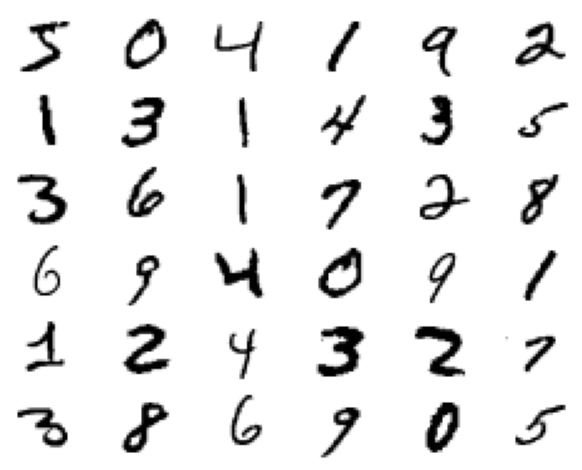

In [153]:
# affichage des données 
fig, ax_array = plt.subplots(6, 6)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray_r")
plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.tight_layout(h_pad=0.5, w_pad=0.01)

In [154]:
# normalisation simple (mise à l'échelle entre 0 et 1)
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

In [155]:
from sklearn import linear_model
# penalty=l2 par défaut
clf = linear_model.LogisticRegression(tol=1e-4, 
                                      solver="lbfgs", C=1, max_iter=2500)

In [156]:
clf.fit(X_train_scaled, Y_train)
Y_pred_train = clf.predict(X_train_scaled)
Y_pred_test = clf.predict(X_test_scaled)

In [159]:
acc_train = accuracy_score(Y_train, Y_pred_train)
print(f"Accuracy on training data = {acc_train:.1%}")

Accuracy on training data = 93.9%


In [160]:
acc_test = accuracy_score(Y_test, Y_pred_test)
print(f"Accuracy on test data = {np.round(100*acc_test)}%")

Accuracy on test data = 93.0%


**A retenir:  
Les principes fondamentaux de l'apprentissage automatique : normalisation des données ; calcul du modèle sur l'ensemble d'entraînement ; sélection des hyperparamètres possibles sur les données de validation ; test du modèle final sur l'ensemble de test.**